## Potrzebne biblioteki

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

import torchvision
from torchvision import transforms, datasets

## Wybór urządzenia

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [3]:
transform = transforms.Compose([transforms.ToTensor()])

dataset = torchvision.datasets.ImageFolder("trafic_32", transform=transform)
dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=64, shuffle=True, num_workers=4
)

## Rozkład próbek w klasach

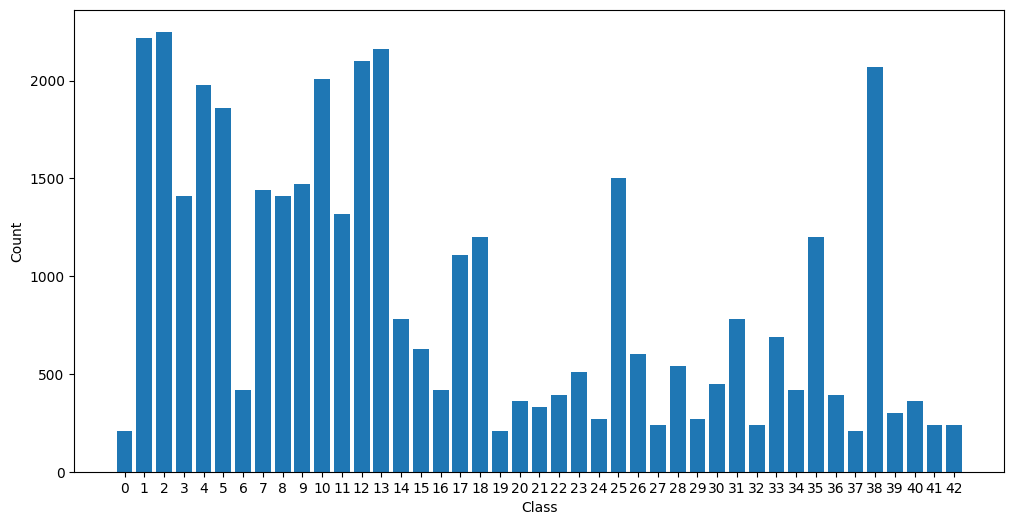

In [4]:
class_counts = Counter(dataset.targets)

classes = list(class_counts.keys())
counts = [class_counts[c] for c in classes]

plt.figure(figsize=(12, 6))
plt.bar(classes, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(classes)
plt.show()

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class DiscriminatorCond(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(DiscriminatorCond, self).__init__()

        self.conv_1 = nn.Conv2d(
            input_dim + num_classes, hidden_dim, 4, 2, 1, bias=False
        )

        self.conv_2 = nn.Conv2d(hidden_dim, hidden_dim * 2, 4, 2, 1, bias=False)
        self.bn_2 = nn.BatchNorm2d(hidden_dim * 2)

        self.conv_3 = nn.Conv2d(hidden_dim * 2, hidden_dim * 4, 4, 2, 1, bias=False)
        self.bn_3 = nn.BatchNorm2d(hidden_dim * 4)

        self.conv_out = nn.Conv2d(hidden_dim * 4, 1, 4, 1, 0, bias=False)

        self.act = nn.LeakyReLU(0.2)

    def forward(self, x, labels):
        x = torch.cat([x, labels], dim=1)

        x = self.act(self.conv_1(x))
        x = self.act(self.bn_2(self.conv_2(x)))
        x = self.act(self.bn_3(self.conv_3(x)))

        x = torch.sigmoid(self.conv_out(x))
        return torch.flatten(x)


class GeneratorCond(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim, num_classes):
        super(GeneratorCond, self).__init__()

        self.conv_1 = nn.ConvTranspose2d(
            latent_dim + num_classes, hidden_dim * 4, 4, 1, 0, bias=False
        )
        self.bn_1 = nn.BatchNorm2d(hidden_dim * 4)

        self.conv_2 = nn.ConvTranspose2d(
            hidden_dim * 4, hidden_dim * 2, 4, 2, 1, bias=False
        )
        self.bn_2 = nn.BatchNorm2d(hidden_dim * 2)

        self.conv_3 = nn.ConvTranspose2d(
            hidden_dim * 2, hidden_dim, 4, 2, 1, bias=False
        )
        self.bn_3 = nn.BatchNorm2d(hidden_dim)

        self.conv_4 = nn.ConvTranspose2d(hidden_dim, output_dim, 4, 2, 1, bias=False)

        self.act = nn.LeakyReLU(0.2)

    def forward(self, x, labels):
        x = torch.cat([x, labels], dim=1)

        h = self.act(self.bn_1(self.conv_1(x)))
        h = self.act(self.bn_2(self.conv_2(h)))
        h = self.act(self.bn_3(self.conv_3(h)))

        x_hat = torch.sigmoid(self.conv_4(h))
        return x_hat

In [ ]:
latent_dim = 128
hidden_dim = 64
channels = 3
num_classes = len(dataset.class_to_idx)

generator = GeneratorCond(
    latent_dim=latent_dim,
    hidden_dim=hidden_dim,
    output_dim=channels,
    num_classes=num_classes,
).to(device)

discriminator = DiscriminatorCond(
    input_dim=channels,
    hidden_dim=hidden_dim,
    num_classes=num_classes,
).to(device)


generator_optimizer = torch.optim.Adam(generator.parameters(), lr=0.0001)
generator_scheduler = optim.lr_scheduler.ExponentialLR(
    optimizer=generator_optimizer, gamma=0.99
)
discriminator_optimizer = torch.optim.Adam(discriminator.parameters(), lr=0.0001)
discriminator_scheduler = optim.lr_scheduler.ExponentialLR(
    optimizer=discriminator_optimizer, gamma=0.99
)

criterion = nn.BCELoss()